# Лабораторная работа 1  
### ПРЕДВАРИТЕЛЬНЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ

ЗАДАЧИ ИССЛЕДОВАНИЯ
1. Исследовать основные описательные статистики для каждого коэффициента
(минимум, максимум, среднее, медиана, стандартное отклонение) с целью ознакомления с
особенностями данных и их распределением.
2. Провести графический анализ данных с целью анализа их распределения на
основе построения гистограмм.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer
import os
from IPython.display import display, Image, HTML
from statsmodels.stats.stattools import medcouple

In [68]:
outdir = 'plots'
os.makedirs(outdir, exist_ok=True)

In [69]:
df = pd.read_spss(r'.\data\data_lab1_start.sav')
df.head(3)
print(df.describe())
print(df.count())
df.drop(columns=["Cреднеспис.числ.работн", "Year"], inplace = True)

       Cреднеспис.числ.работн           k1           k2           k3  \
count             2695.000000  2695.000000  2695.000000  2695.000000   
mean              1220.773284     2.002089     0.238018     0.825098   
std               2556.406482     1.690052     0.517697     0.918292   
min                 10.000000     0.248322     0.000000     0.008329   
25%                229.500000     1.097990     0.017088     0.317674   
50%                473.000000     1.473859     0.055551     0.538349   
75%               1128.500000     2.238232     0.211538     0.941372   
max              28650.000000    18.020148     7.029135    11.187699   

                k4       k4_new           k5           k6           k7  \
count  2695.000000  1540.000000  2695.000000  2695.000000  2695.000000   
mean      0.038115     0.335777     0.346330     0.238031     0.174212   
std       0.625155     0.360196     0.198008     0.213094     0.223266   
min      -4.569874    -2.599123     0.009944     0.0000

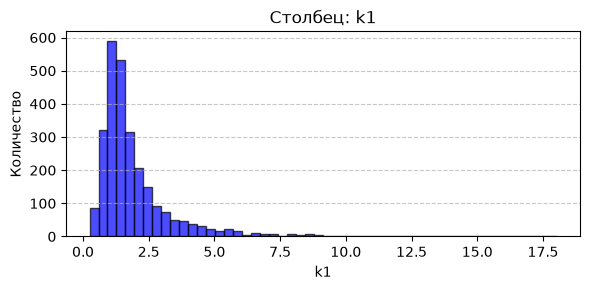

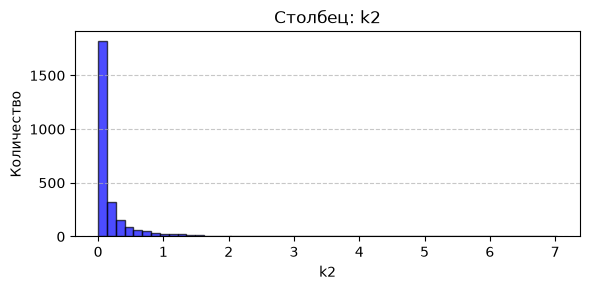

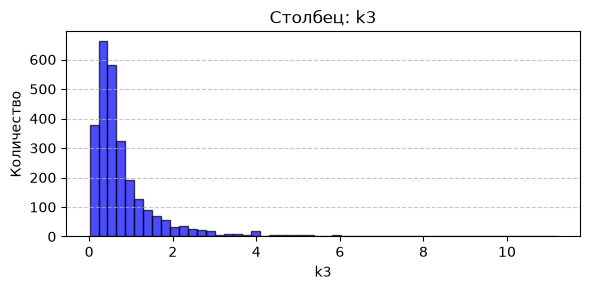

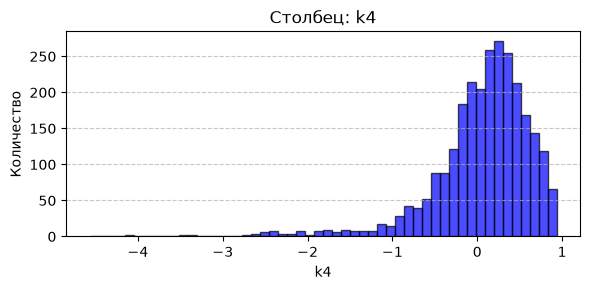

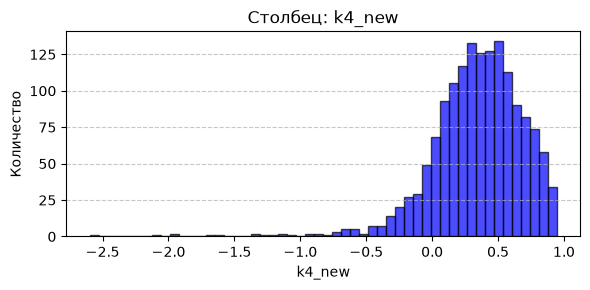

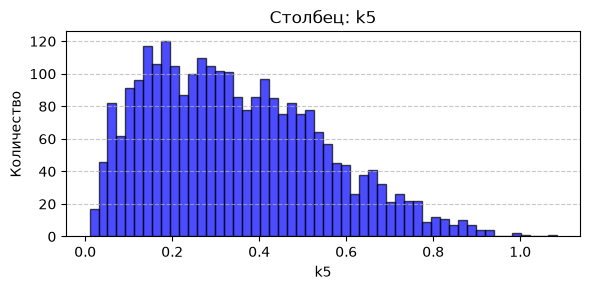

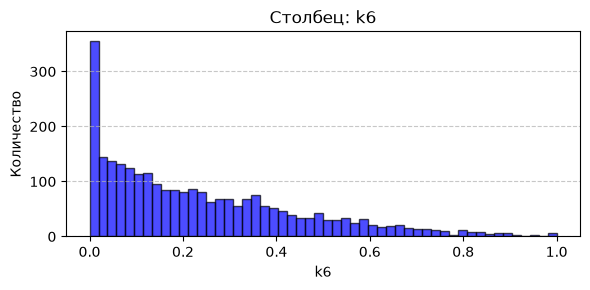

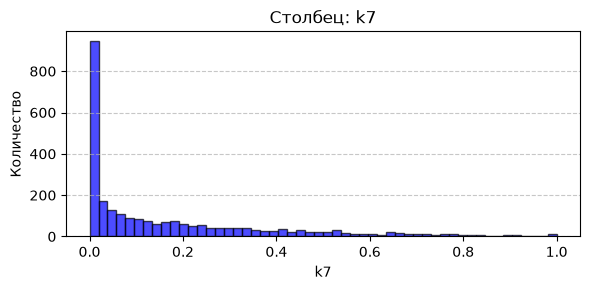

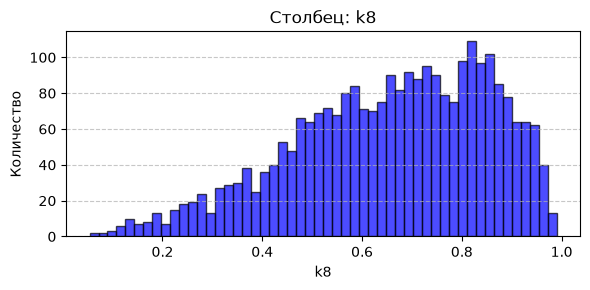

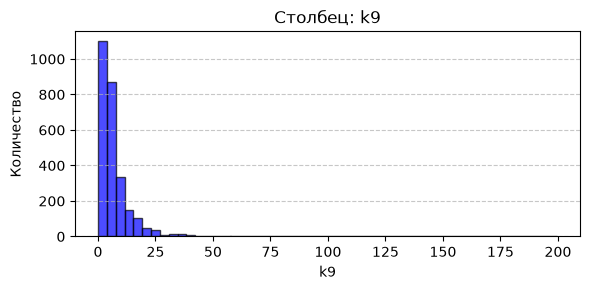

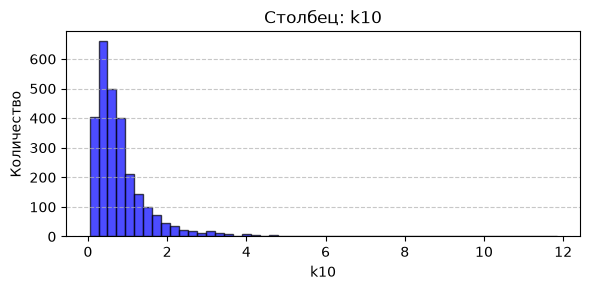

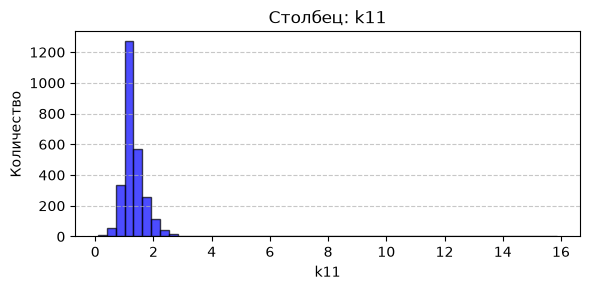

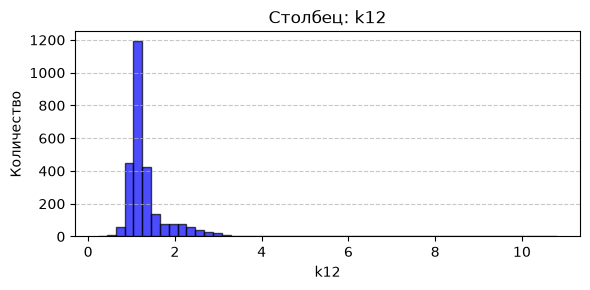

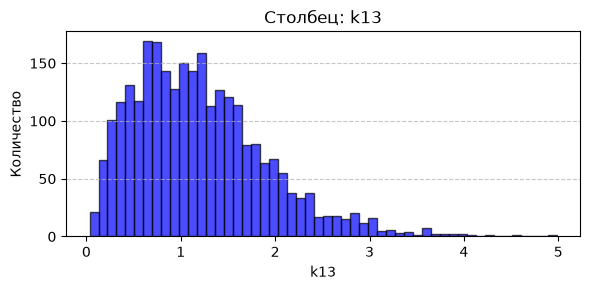

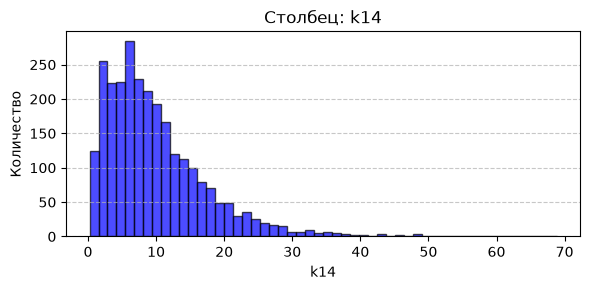

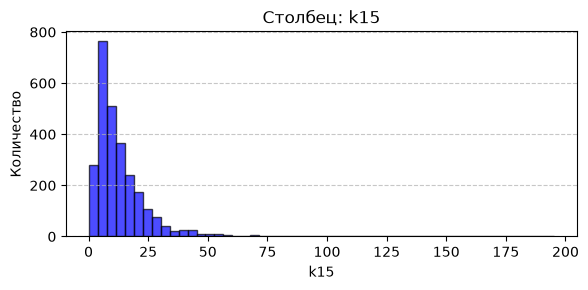

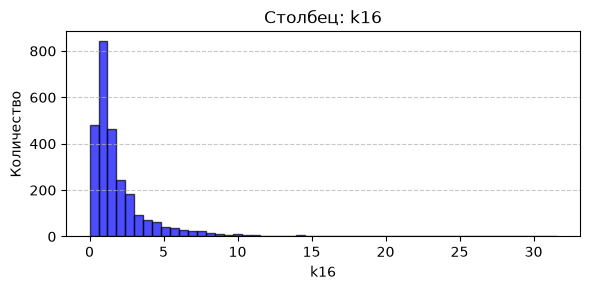

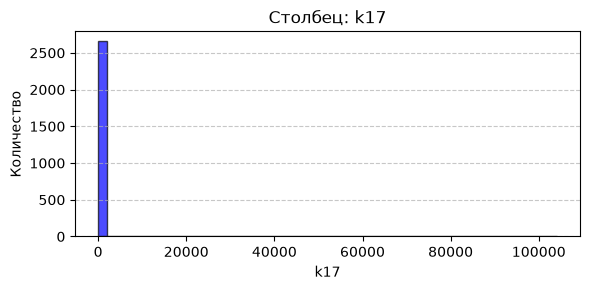

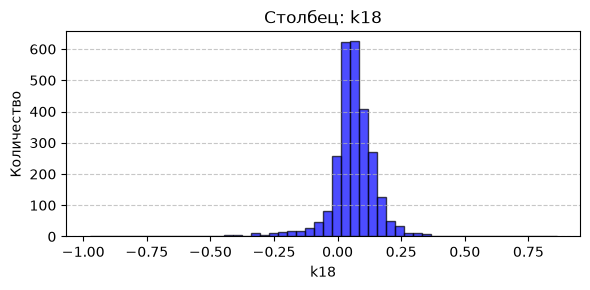

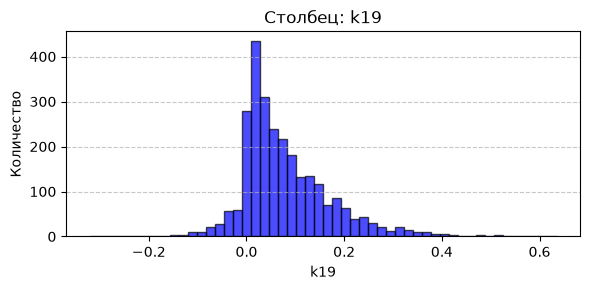

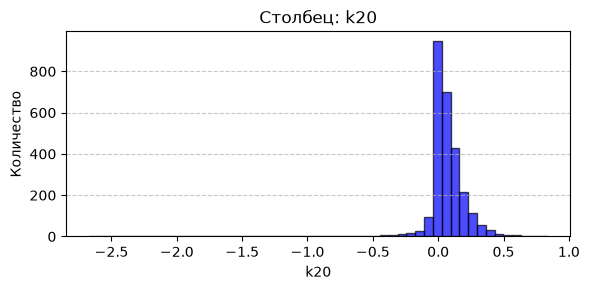

In [70]:
num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.hist(df[col].dropna(), bins=52, color='blue', edgecolor='black', alpha=0.7)
    plt.title(f"Столбец: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")
    plt.grid(axis='y', linestyle='--', alpha = 0.7)
    plt.tight_layout() 
    plt.savefig(f'{outdir}/{col}_hist1.png')
    plt.show()

Похожим на нормальное распределение являются коэффициенты К18-К20  

ЗАДАЧИ ИССЛЕДОВАНИЯ
1. Провести графический анализ данных с целью выявления аномальных
наблюдений на основе построения ящичных диаграмм.
2. На основании условия ниже или «правила шести сигм» определить экстремальные
наблюдения в выборке. Множитель в это условие подобрать таким образом, чтобы
экстремальными признавалось не более 5-8% наблюдений
3. Провести цензурирование и нормировку данных.

$$[x_{med} - 5.2 \cdot x_{mad}, \ x_{med} + 5.2 \cdot x_{mad}]$$

где:
* $x_{med}$ — медиана выборки $\{x_i\}$
* $x_{mad}$ — медиана выборки $\{|x_i - x_{med}|\} \ (i = \overline{1, n})$ абсолютных отклонений от $x_{med}$


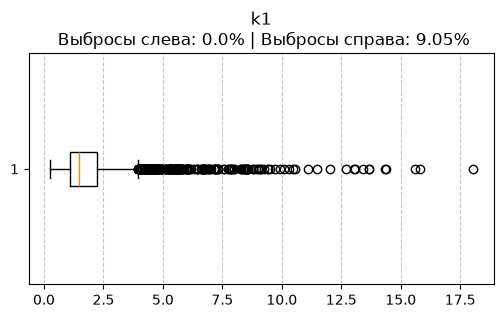

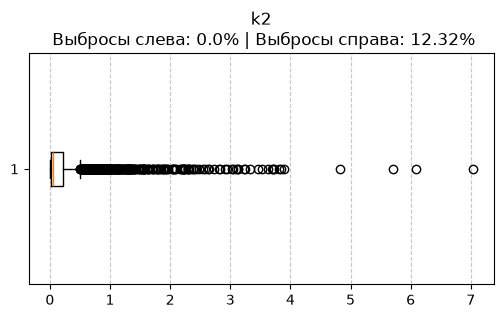

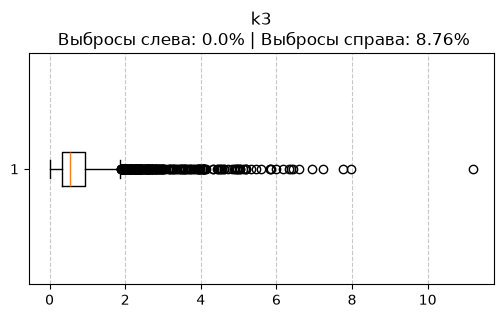

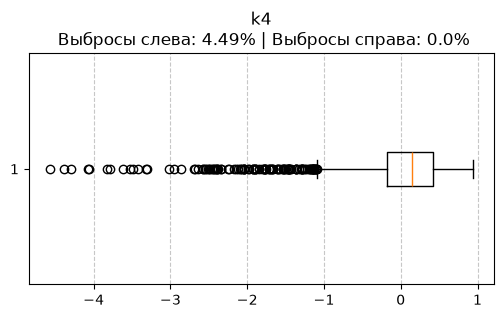

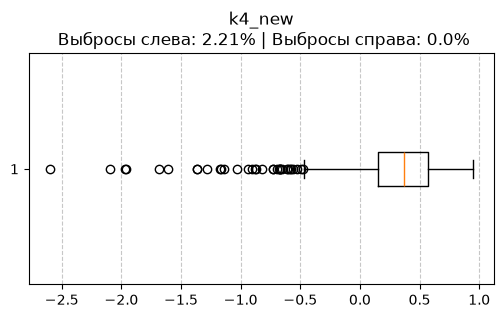

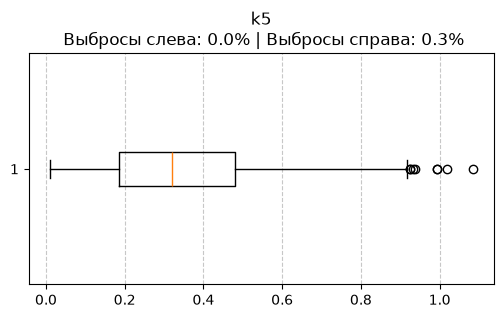

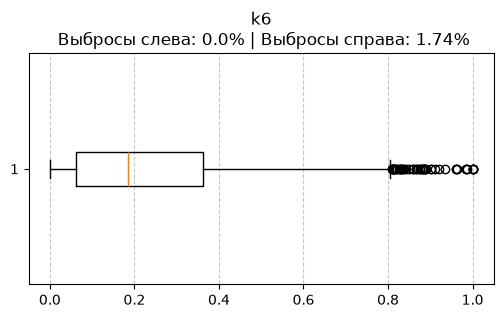

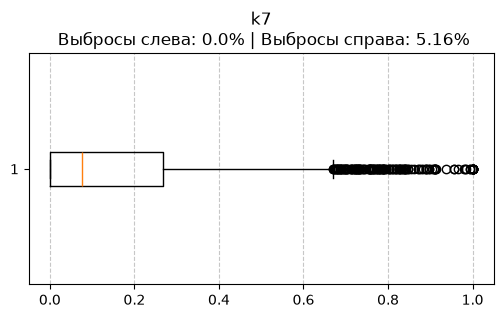

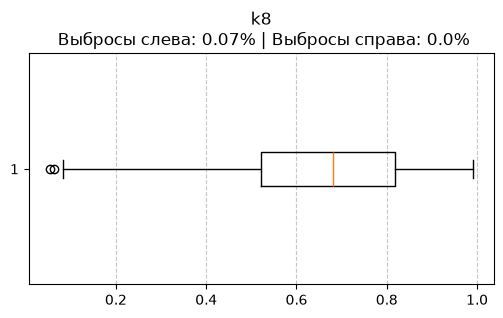

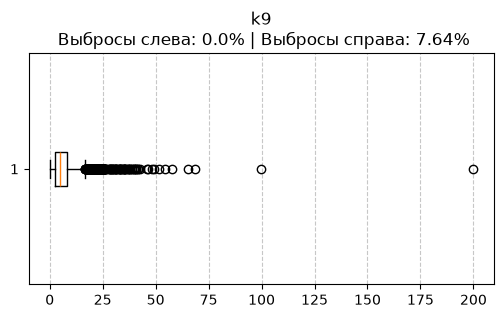

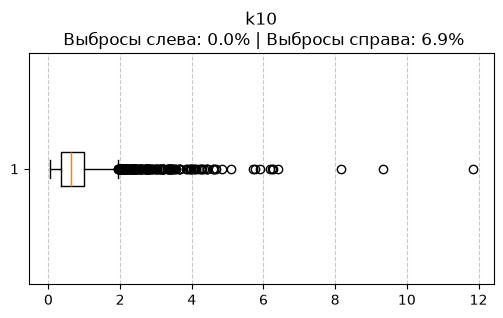

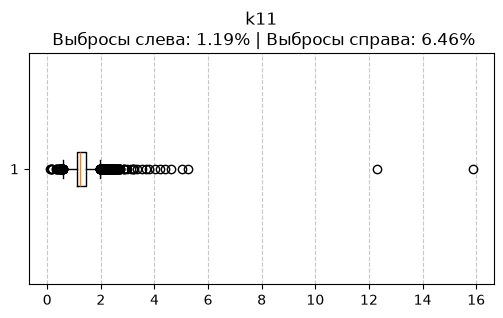

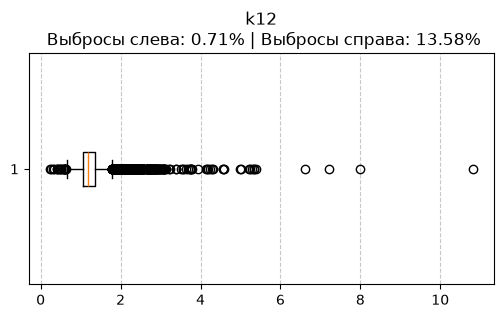

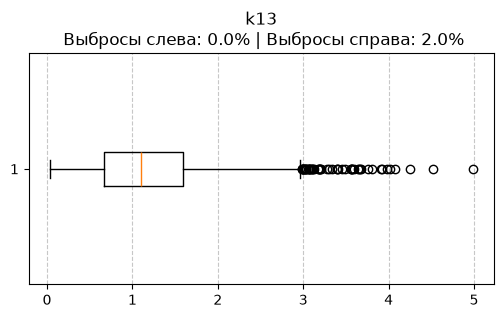

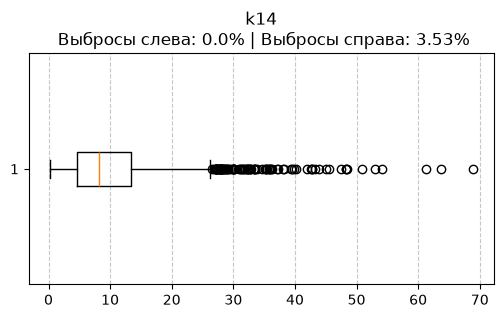

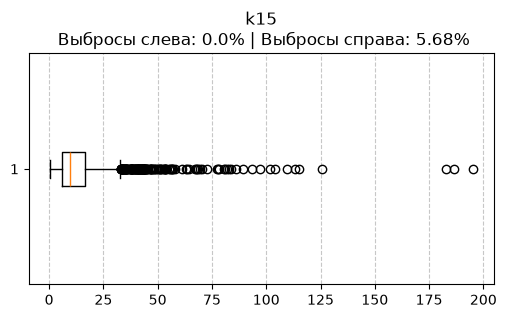

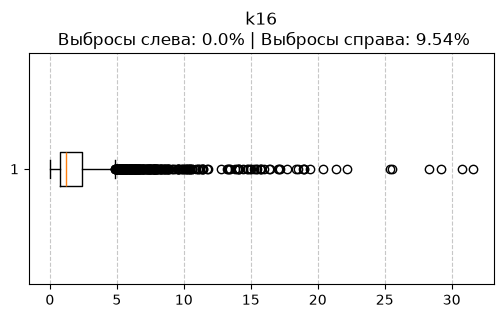

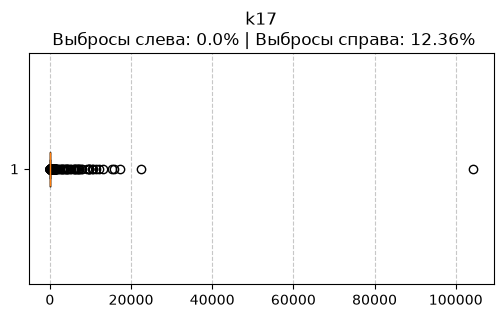

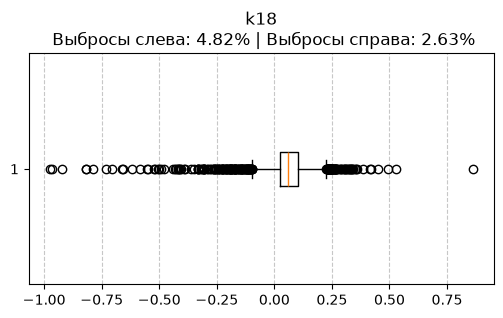

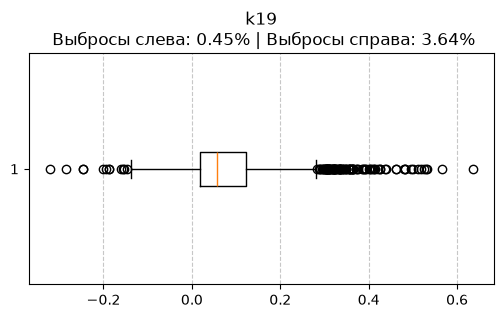

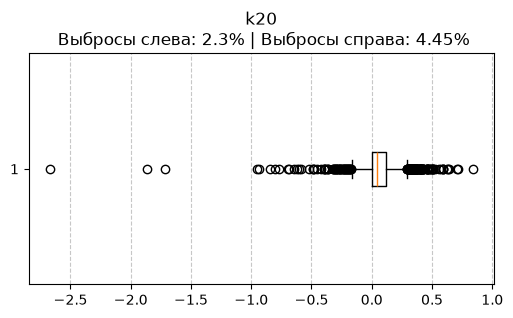

Итоговая статистика:
k1: Выбросы слева: 0.0% | Выбросы справа: 9.05%
k2: Выбросы слева: 0.0% | Выбросы справа: 12.32%
k3: Выбросы слева: 0.0% | Выбросы справа: 8.76%
k4: Выбросы слева: 4.49% | Выбросы справа: 0.0%
k4_new: Выбросы слева: 2.21% | Выбросы справа: 0.0%
k5: Выбросы слева: 0.0% | Выбросы справа: 0.3%
k6: Выбросы слева: 0.0% | Выбросы справа: 1.74%
k7: Выбросы слева: 0.0% | Выбросы справа: 5.16%
k8: Выбросы слева: 0.07% | Выбросы справа: 0.0%
k9: Выбросы слева: 0.0% | Выбросы справа: 7.64%
k10: Выбросы слева: 0.0% | Выбросы справа: 6.9%
k11: Выбросы слева: 1.19% | Выбросы справа: 6.46%
k12: Выбросы слева: 0.71% | Выбросы справа: 13.58%
k13: Выбросы слева: 0.0% | Выбросы справа: 2.0%
k14: Выбросы слева: 0.0% | Выбросы справа: 3.53%
k15: Выбросы слева: 0.0% | Выбросы справа: 5.68%
k16: Выбросы слева: 0.0% | Выбросы справа: 9.54%
k17: Выбросы слева: 0.0% | Выбросы справа: 12.36%
k18: Выбросы слева: 4.82% | Выбросы справа: 2.63%
k19: Выбросы слева: 0.45% | Выбросы справа: 3.64%
k

In [71]:
summary = {}

for col in num_cols:
    plt.figure(figsize=(6,3))
    bp = plt.boxplot(df[col].dropna(), orientation='horizontal')

    total_count = len(df[col].dropna())
    left_whisker = bp['whiskers'][0].get_xdata()[0]   
    right_whisker= bp['whiskers'][1].get_xdata()[1]
    noise = bp['fliers'][0].get_xdata()

    left_noise_count = len(noise[noise < left_whisker])
    right_noise_count = len(noise[noise > right_whisker])

    if total_count > 0:
        left_prc = round((left_noise_count / total_count) * 100, 2)
        right_prc = round((right_noise_count / total_count) * 100, 2)
    else:
        left_prc = right_prc = 0.0

    summary[col] = {
        'total_count': total_count,
        'left_noise_count': left_noise_count,
        'right_noise_count': right_noise_count,
        'left_prc': left_prc,
        'right_prc': right_prc
    }


    plt.title(f"{col}\n Выбросы слева: {left_prc}% | Выбросы справа: {right_prc}%")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.savefig(f'{outdir}/{col}_box1.png')
    plt.show()

print("Итоговая статистика:")
for stat, data in summary.items():
    print(f"{stat}: Выбросы слева: {data['left_prc']}% | Выбросы справа: {data['right_prc']}%")

k1:  6.72% 181
k2:  6.98% 188
k3:  6.75% 182
k4:  6.46% 174
k4_new:  4.42% 68
k5:  3.30% 89
k6:  5.45% 147
k7:  6.68% 180
k8:  3.27% 88
k9:  6.86% 185
k10:  6.86% 185
k11:  6.46% 174
k12:  6.83% 184
k13:  5.34% 144
k14:  6.09% 164
k15:  6.27% 169
k16:  6.68% 180
k17:  6.98% 188
k18:  6.42% 173
k19:  6.27% 169
k20:  6.86% 185


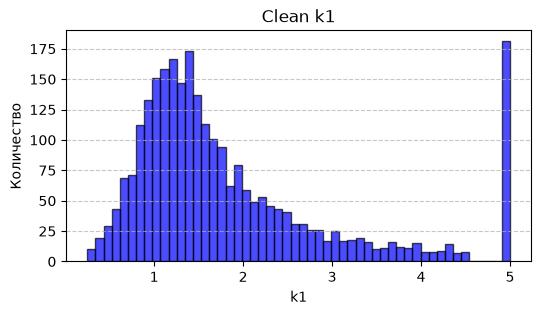

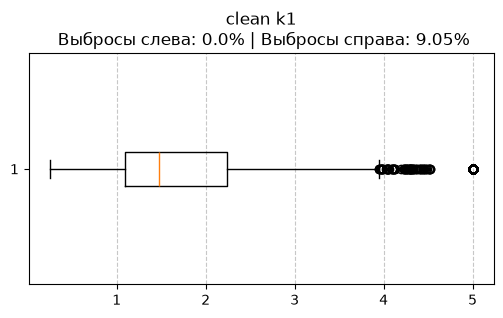

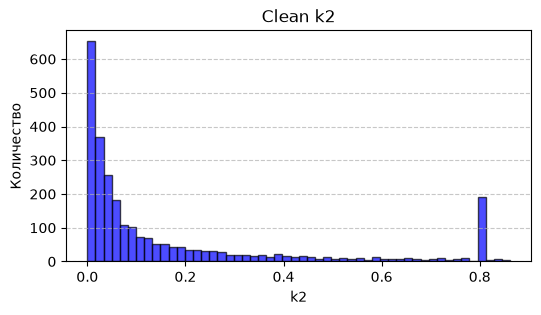

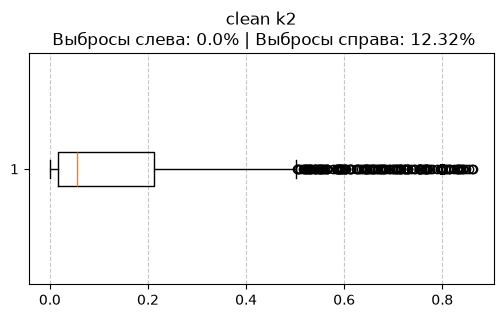

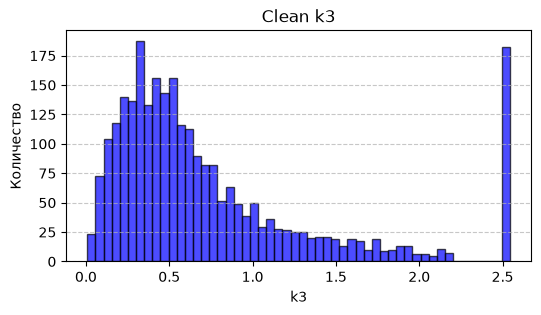

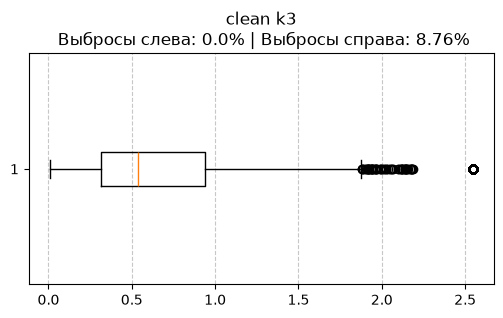

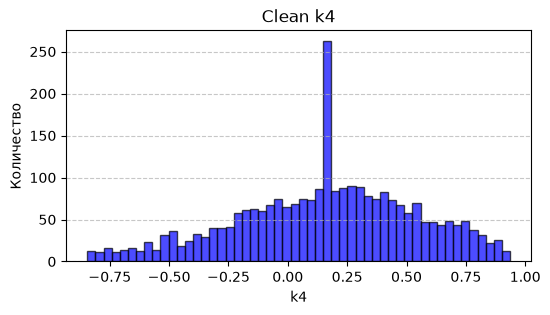

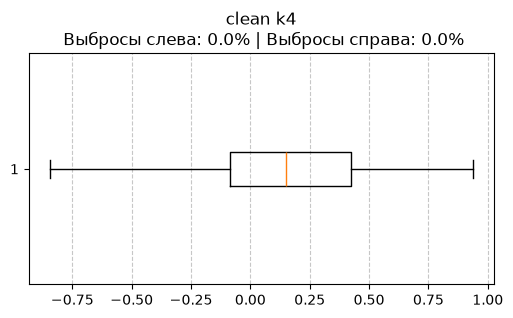

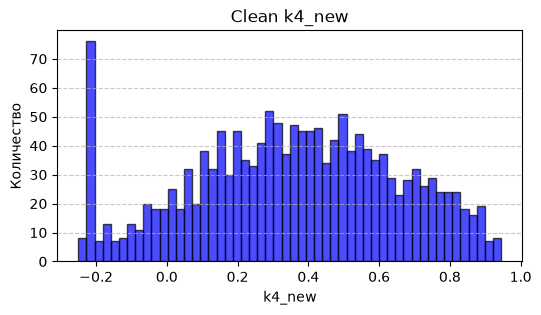

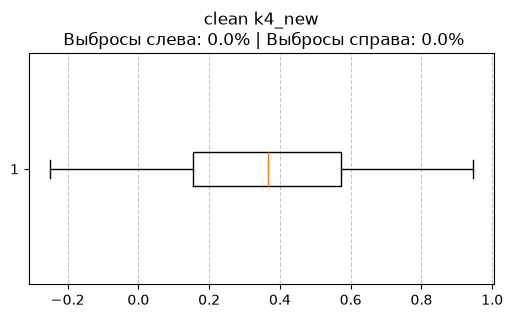

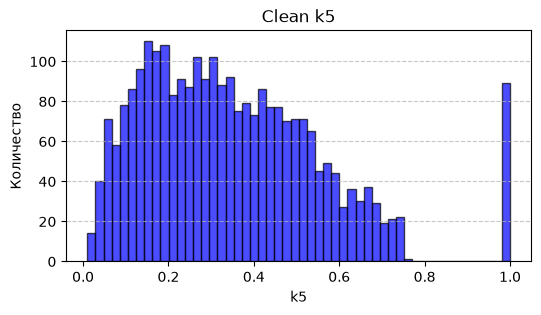

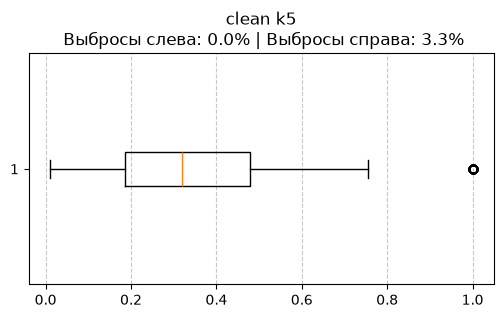

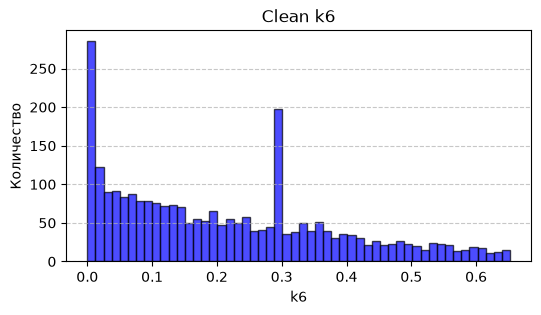

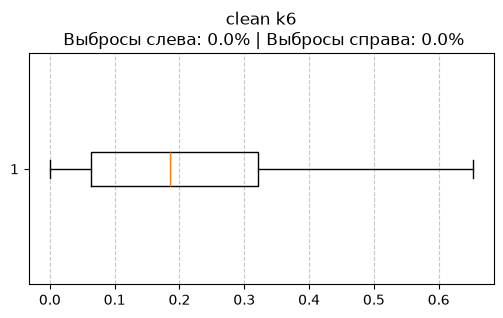

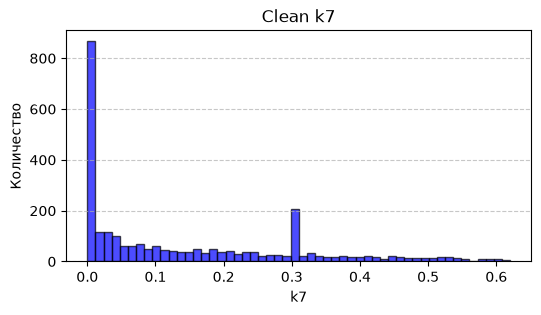

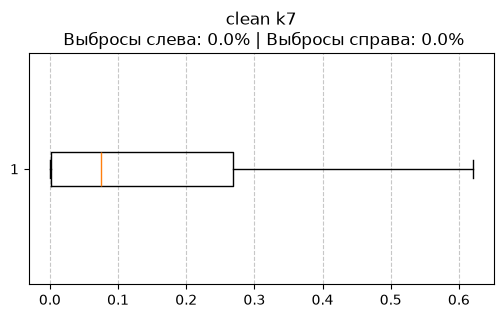

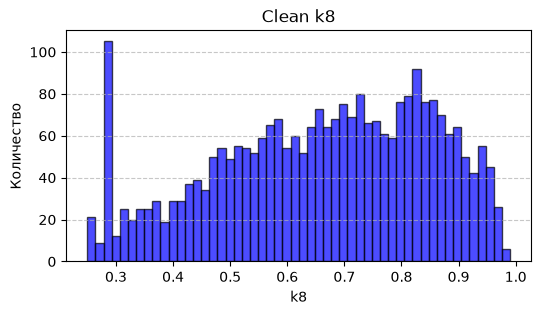

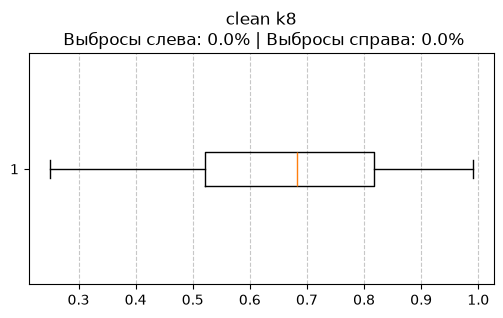

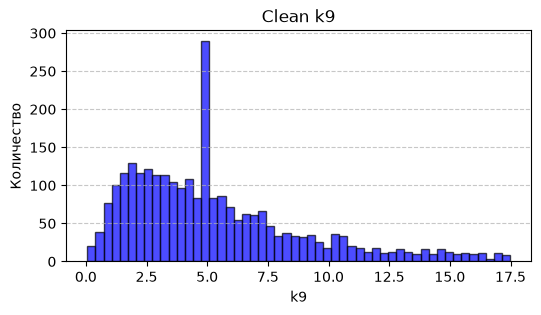

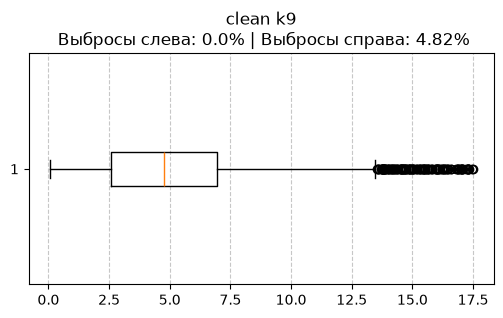

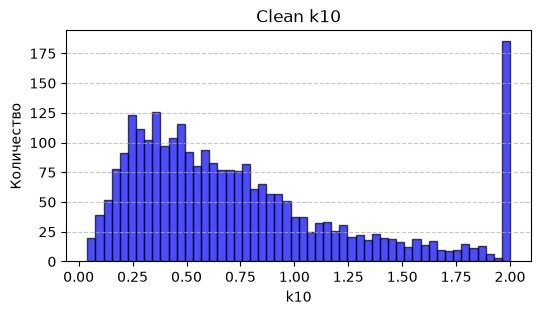

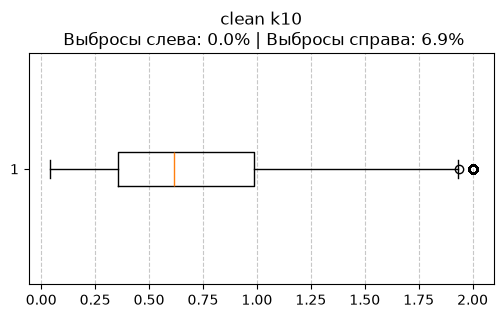

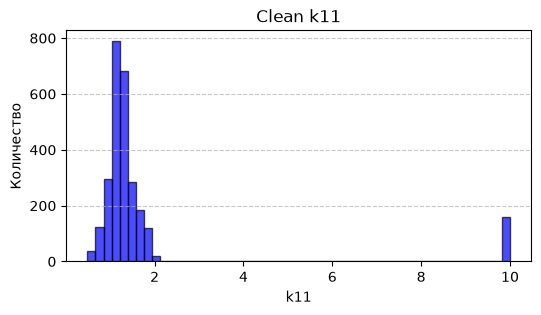

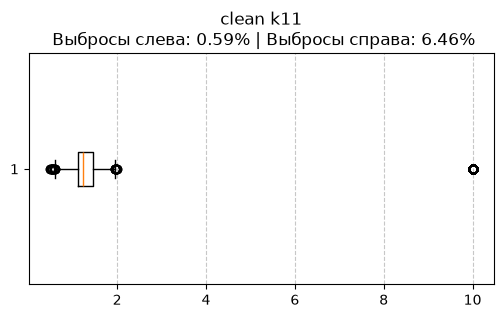

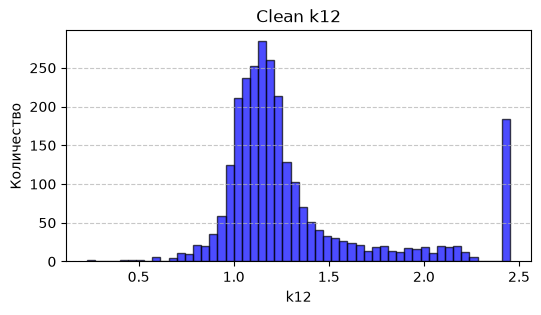

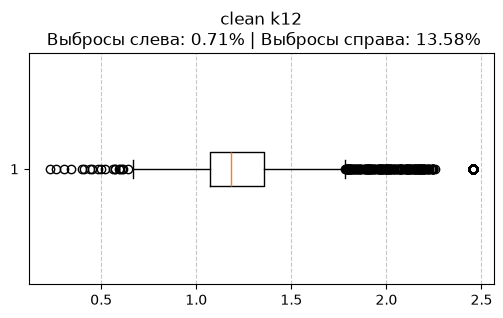

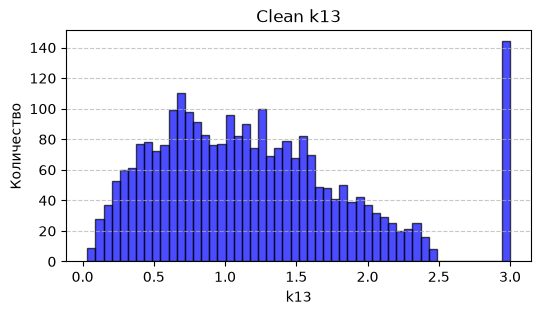

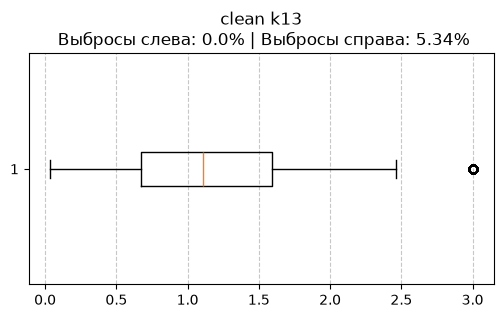

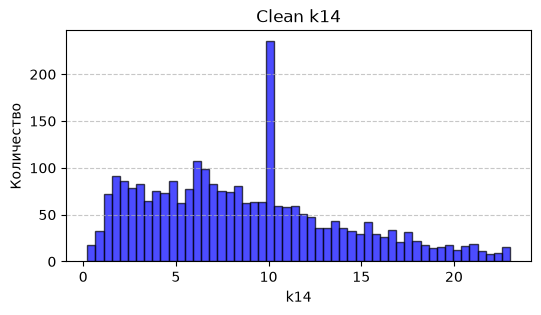

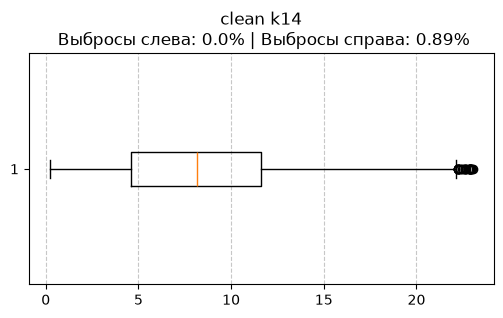

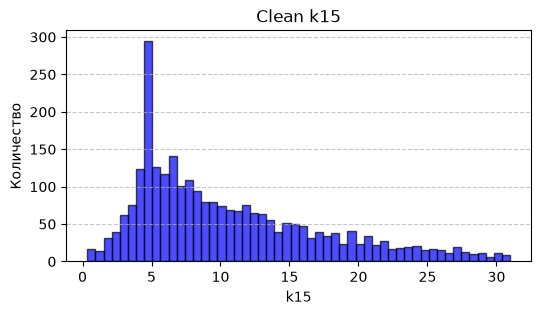

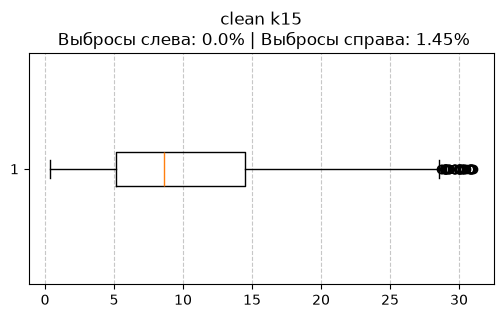

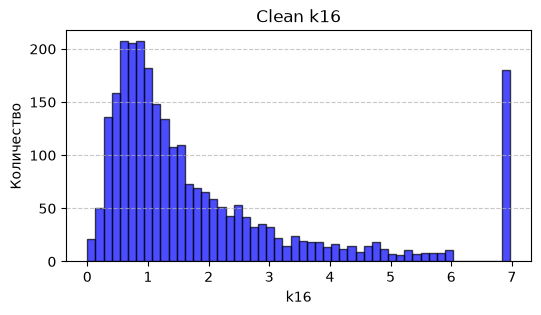

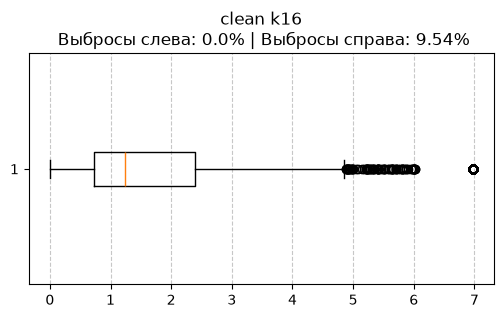

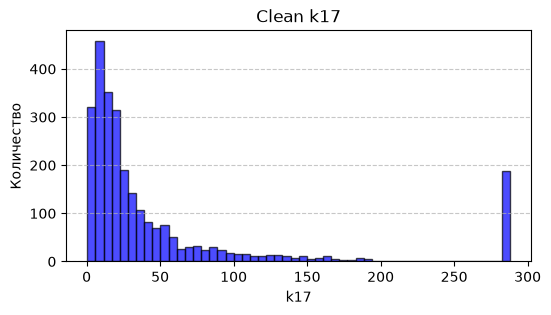

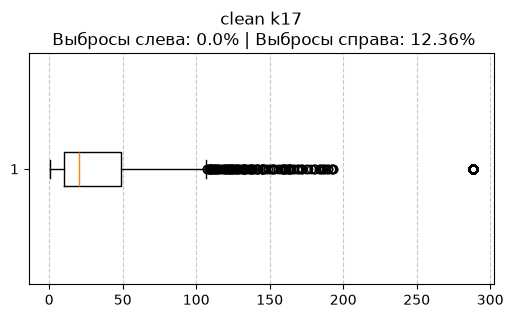

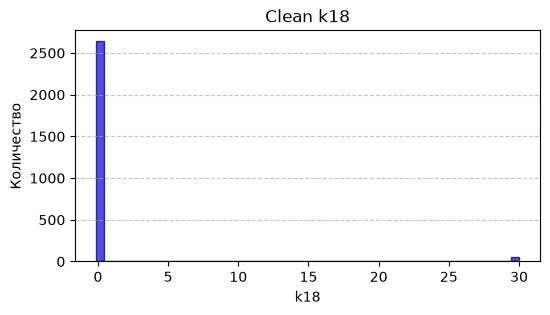

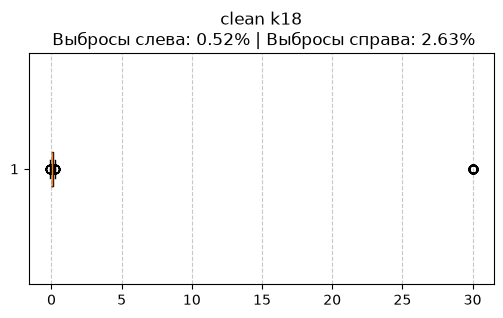

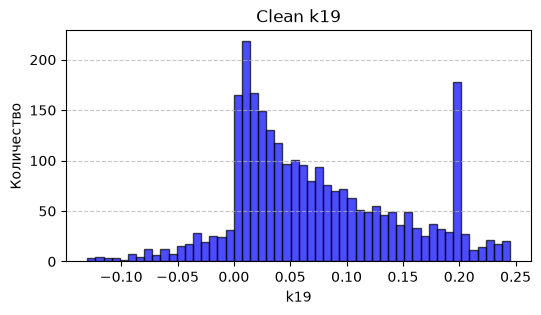

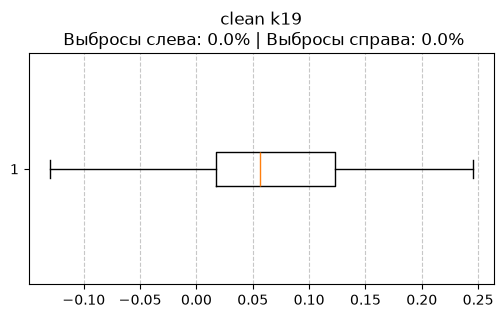

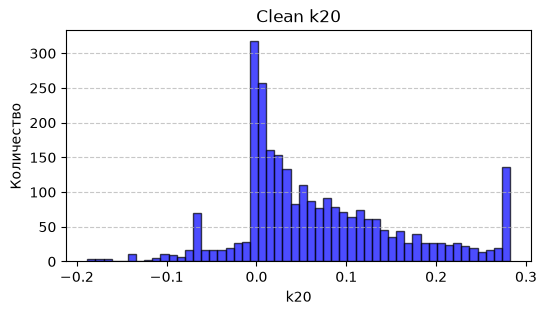

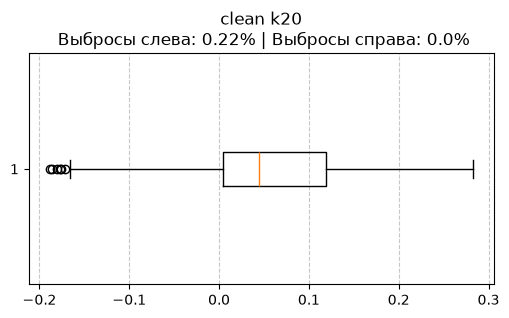

In [ ]:
def hampel_test(data, col, dict_ = None, mul=3):
    working_data = data.copy()
    perc = 1
    while perc > 0.07:
        clean_data = data.dropna()
        med = clean_data.median()
        mad = (clean_data - med).abs().median()
        left_bound = med - mul * mad
        right_bound = med + mul * mad
        mask = (clean_data < left_bound) | (clean_data > right_bound)
        perc = mask.sum() / len(clean_data)
        mul += 0.3
    if col in dict_:
        low_val = dict_[col][0]   
        high_val = dict_[col][1]  
    else:
        low_val = clean_data.quantile(0.02)  
        high_val = clean_data.quantile(0.98)
    working_data.loc[working_data < left_bound] = low_val
    working_data.loc[working_data > right_bound] = high_val
    print(f"{(perc * 100):.2f}% {mask.sum()}")
    return working_data

K = {
    'k1': (1.0, 5.0),
    'k2': (0.05, 0.8),
    'k4': (0.15, 1.0),
    'k5': (0.0, 1.0),
    'k6': (0.0, 0.3),
    'k7': (0.0, 0.3),
    'k9': (0.8, 5.0),
    'k10': (0.3, 2.0),
    'k11': (1.0, 10.0),
    'k13': (0.5, 3.0),
    'k14': (1.0, 10.0),
    'k15': (0.0, 5.0),
    'k18': (0.0, 30.0),
    'k19': (0.0, 0.2)
}


df_clean = df.copy()
for col in num_cols:
    print(f"{col}: ", end=' ')
    df_clean[col] = hampel_test(df[col], dict_=K, col=col)


for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.hist(df_clean[col].dropna(), bins=52, color='blue', edgecolor='black', alpha=0.7)
    plt.title(f"Clean {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")
    plt.grid(axis='y', linestyle='--', alpha = 0.7)
    plt.savefig(f'{outdir}/{col}_hist2.png')
    plt.show()
    
    plt.figure(figsize=(6,3))
    bp = plt.boxplot(df_clean[col].dropna(), orientation='horizontal')

    total_count = len(df_clean[col].dropna())
    left_whisker = bp['whiskers'][0].get_xdata()[0]   
    right_whisker= bp['whiskers'][1].get_xdata()[1]
    noise = bp['fliers'][0].get_xdata()

    left_noise_count = len(noise[noise < left_whisker])
    right_noise_count = len(noise[noise > right_whisker])

    if total_count > 0:
        left_prc = round((left_noise_count / total_count) * 100, 2)
        right_prc = round((right_noise_count / total_count) * 100, 2)
    else:
        left_prc = right_prc = 0.0

    summary[col] = {
        'total_count': total_count,
        'left_noise_count': left_noise_count,
        'right_noise_count': right_noise_count,
        'left_prc': left_prc,
        'right_prc': right_prc
    }


    plt.title(f"clean {col}\n Выбросы слева: {left_prc}% | Выбросы справа: {right_prc}%")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.savefig(f'{outdir}/{col}_box2.png')
    plt.show()

    

После удаления шума с помощью теста Хампеля получили более читаемы боксплоты, но все равно в них достаточно много объектов классифицируются как шумовые. Удалять их нельзя, потому что это приведет к сильному сокращению выборки

### 1. Расчет коэффициента Medcouple (MC)

Для выборки $\{x_1, \dots, x_n\}$ коэффициент **Medcouple (MC)** определяется как медиана значений функции ядра $h(x_i, x_j)$, вычисленная по всем парам, для которых $x_i \leq Q_2 \leq x_j$:

$$MC = \operatorname{med}_{x_i \leq Q_2 \leq x_j} h(x_i, x_j)$$

Где $Q_2$ — медиана выборки, а функция ядра $h(x_i, x_j)$ для всех $x_i \neq x_j$ рассчитывается по формуле:

$$h(x_i, x_j) = \frac{(x_j - Q_2) - (Q_2 - x_i)}{x_j - x_i}$$

---

### 2. Границы Adjusted Boxplot с учетом MC

После расчета $MC$ границы усов определяются следующим образом ($IQR = Q_3 - Q_1$):

**Если $MC \geq 0$ (положительная асимметрия):**
$$\text{Нижний ус} = Q_1 - 1.5 \cdot e^{-4 \cdot MC} \cdot IQR$$
$$\text{Верхний ус} = Q_3 + 1.5 \cdot e^{3 \cdot MC} \cdot IQR$$

**Если $MC < 0$ (отрицательная асимметрия):**
$$\text{Нижний ус} = Q_1 - 1.5 \cdot e^{-3 \cdot MC} \cdot IQR$$
$$\text{Верхний ус} = Q_3 + 1.5 \cdot e^{4 \cdot MC} \cdot IQR$$

**Ограничение по реальным границам данных:**
$$\text{Итоговый нижний ус} = \max(\text{Нижний ус}, \min(X))$$
$$\text{Итоговый верхний ус} = \min(\text{Верхний ус}, \max(X))$$


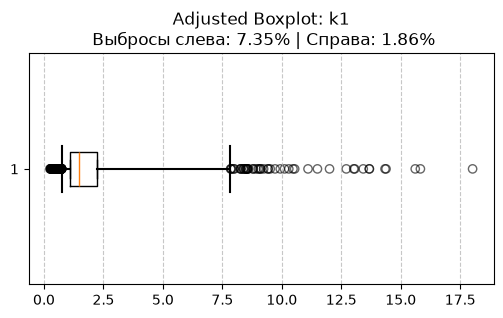

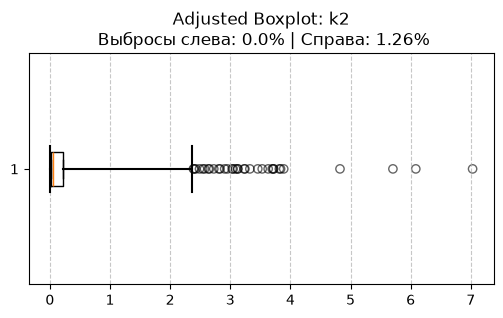

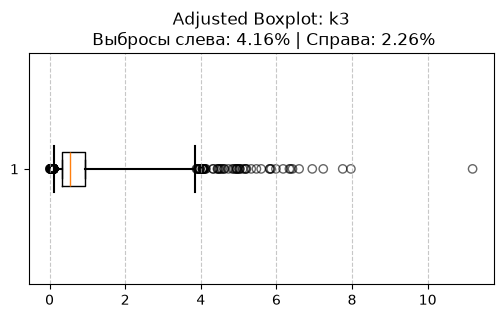

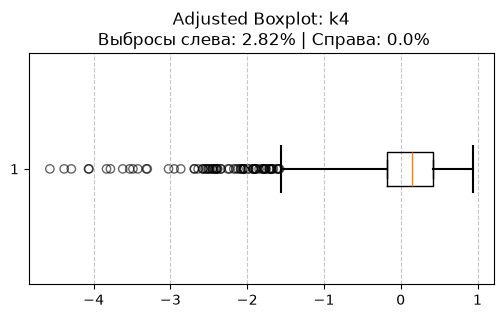

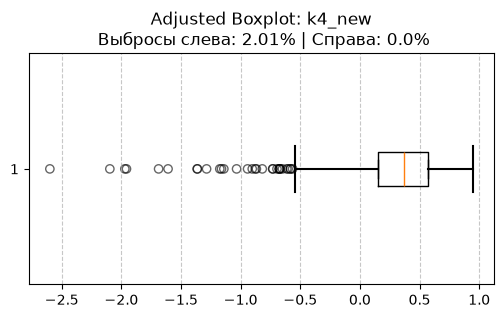

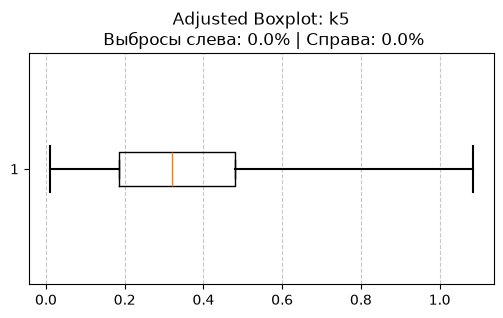

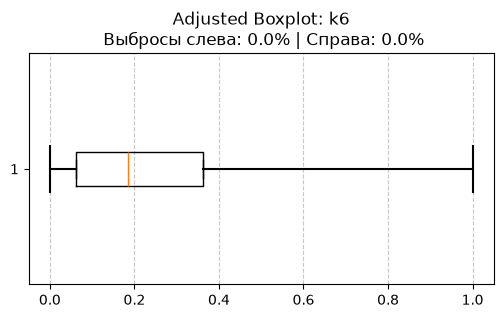

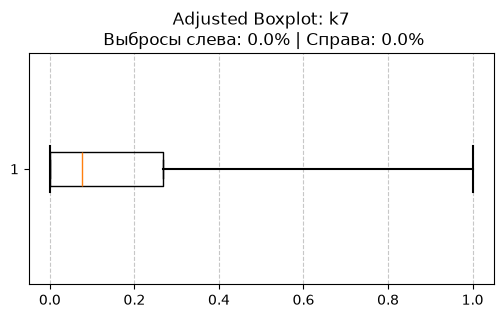

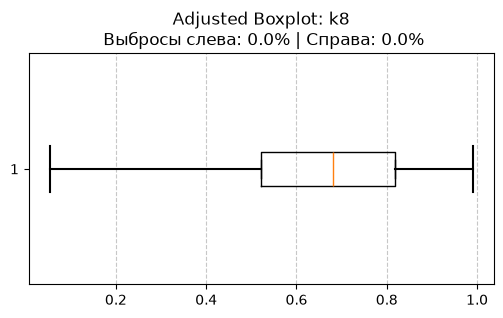

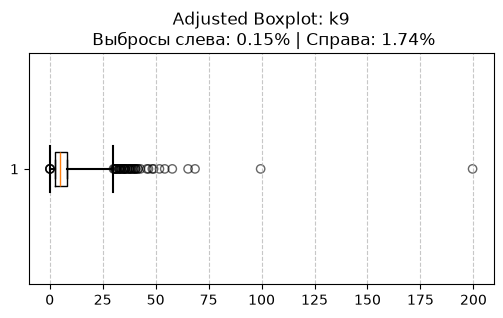

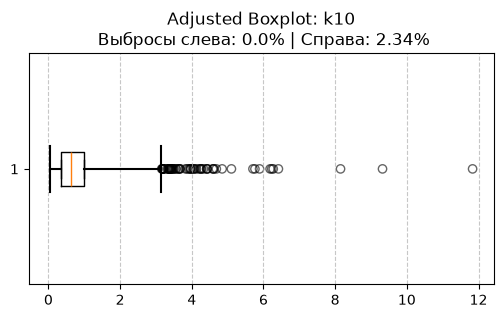

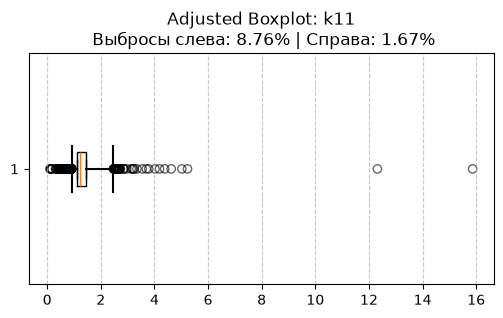

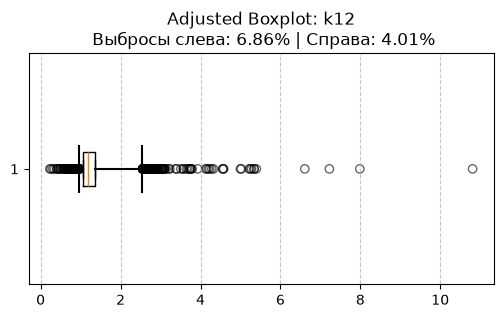

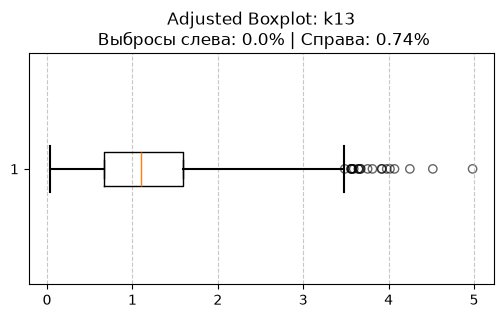

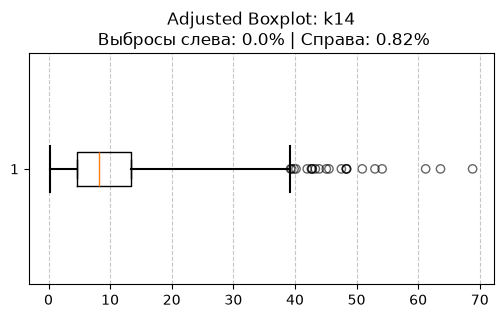

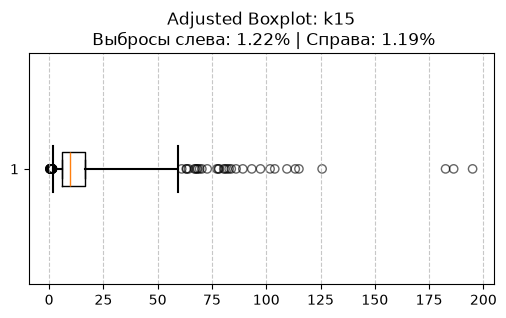

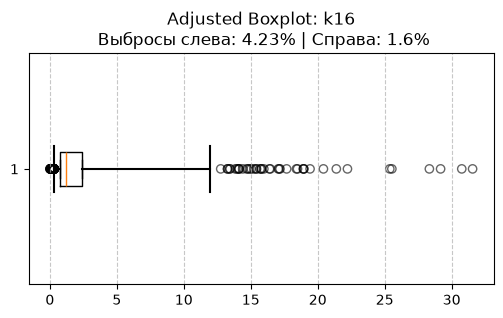

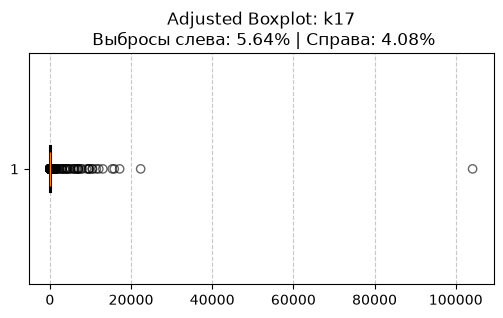

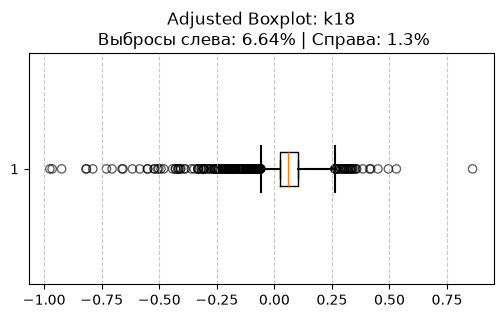

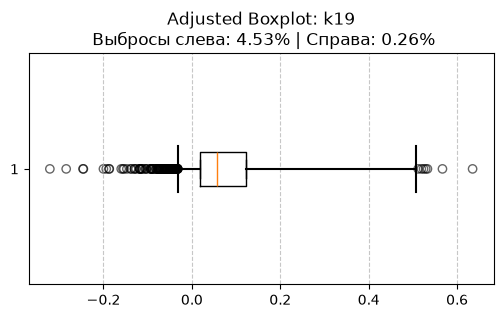

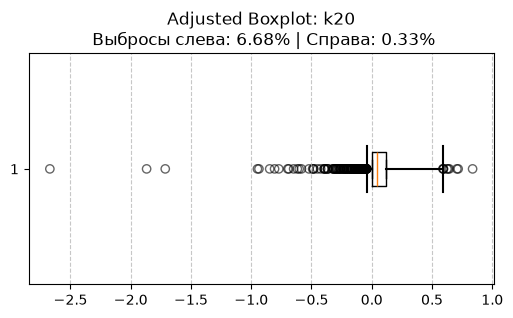

In [73]:
def adj_boxplot(data):
    clean_data = data.dropna().to_numpy()
    col_name = data.name    

    q25, q75 = np.percentile(clean_data, [25, 75])
    iqr = q75 - q25
    mc = medcouple(clean_data)

    if mc >= 0:
        left_whisker = q25 - 1.5 * np.exp(-4 * mc) * iqr
        right_whisker = q75 + 1.5 * np.exp(3 * mc) * iqr
    else:
        left_whisker = q25 - 1.5 * np.exp(-3 * mc) * iqr
        right_whisker = q75 + 1.5 * np.exp(4 * mc) * iqr

    left_whisker = max(left_whisker, clean_data.min())
    right_whisker = min(right_whisker, clean_data.max())
    outliers = clean_data[(clean_data < left_whisker) | (clean_data > right_whisker)]
    
    total_count = len(clean_data)
    left_outliers = outliers[outliers < left_whisker]
    right_outliers = outliers[outliers > right_whisker]
    
    left_prc = round((len(left_outliers) / total_count) * 100, 2)
    right_prc = round((len(right_outliers) / total_count) * 100, 2)

    plt.figure(figsize=(6, 3))
    bp = plt.boxplot(clean_data, orientation='horizontal', positions=[1], showfliers=False, whis=0)
    
    plt.plot([left_whisker, q25], [1, 1], color='black', linestyle='-')
    plt.plot([q75, right_whisker], [1, 1], color='black', linestyle='-')
    

    plt.plot([left_whisker, left_whisker], [0.9, 1.1], color='black', linestyle='-')
    plt.plot([right_whisker, right_whisker], [0.9, 1.1], color='black', linestyle='-')
    
    if len(left_outliers) > 0:
        plt.scatter(left_outliers, np.ones_like(left_outliers), color='black', facecolors='none', edgecolors='black', alpha=0.6)
    if len(right_outliers) > 0:
        plt.scatter(right_outliers, np.ones_like(right_outliers), color='black', facecolors='none', edgecolors='black', alpha=0.6)
        
    
    plt.title(f"Adjusted Boxplot: {col_name}\n Выбросы слева: {left_prc}% | Справа: {right_prc}%")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.ylim(0.5, 1.5) 
    plt.savefig(f'{outdir}/{col_name}_box3.png')
    plt.show()


for col in num_cols:
    adj_boxplot(df[col])



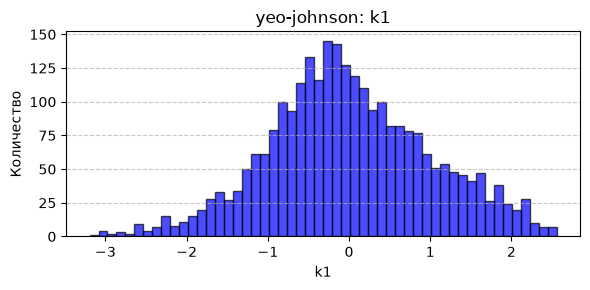

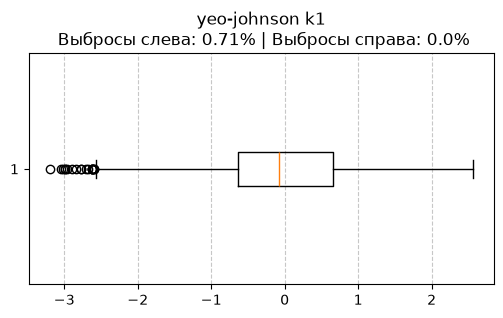

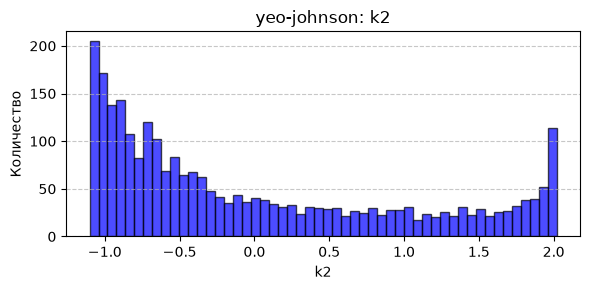

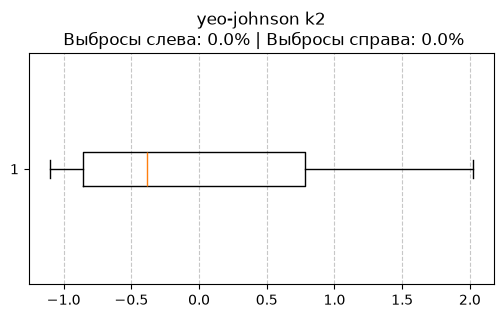

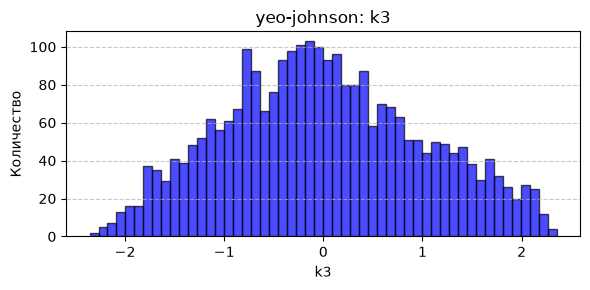

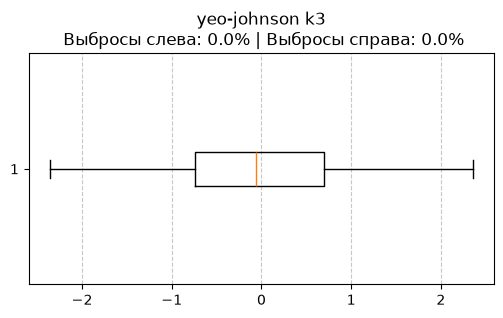

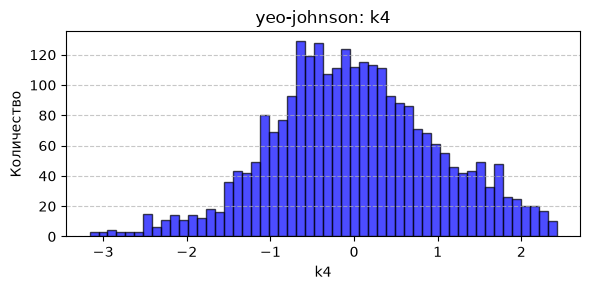

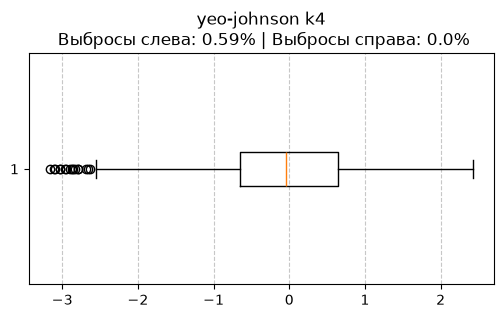

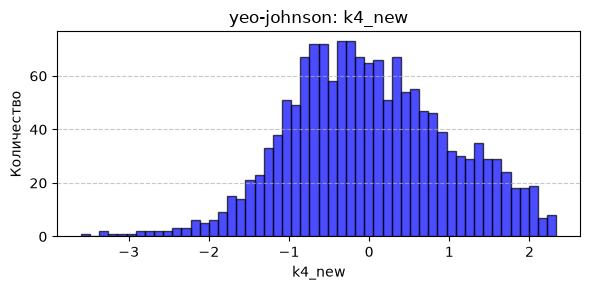

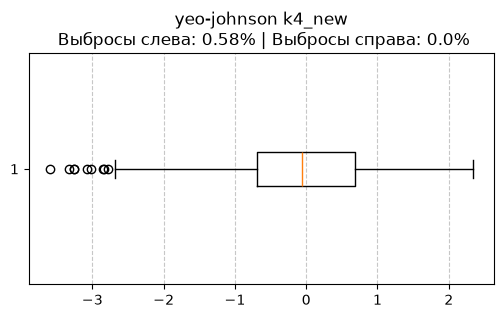

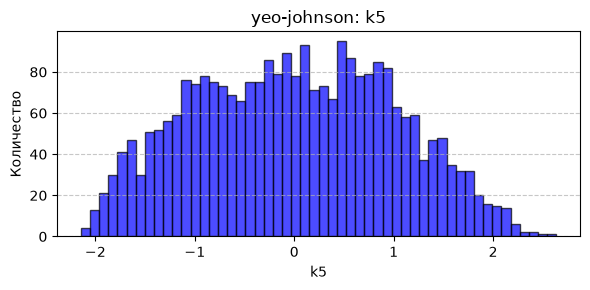

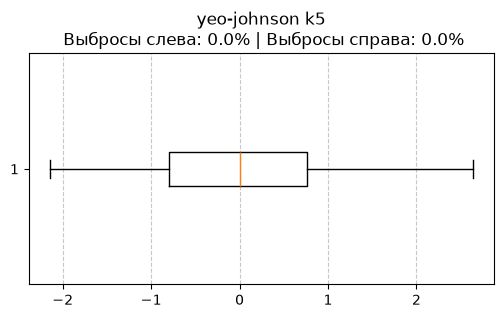

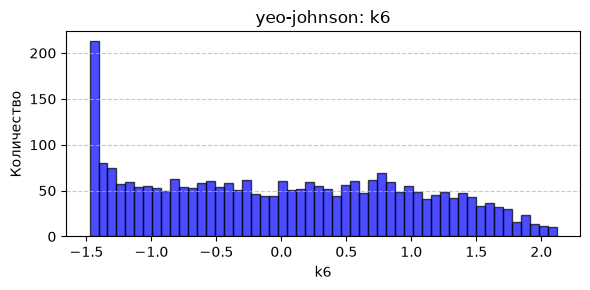

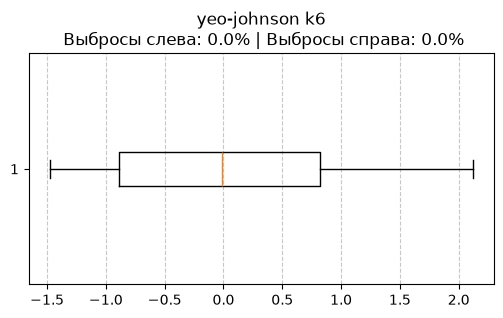

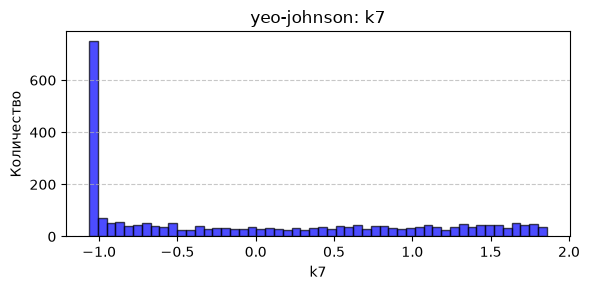

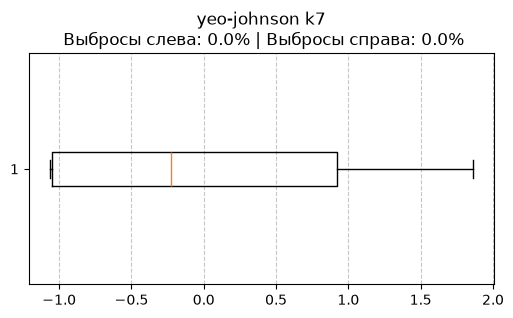

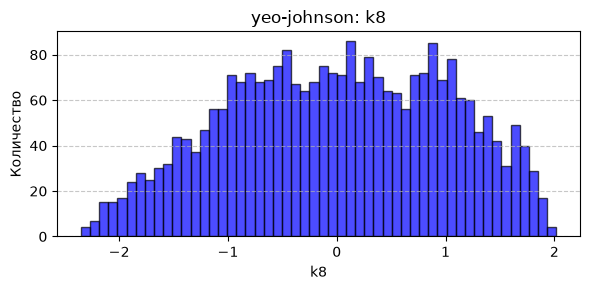

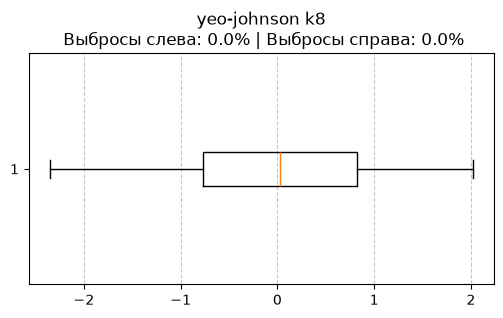

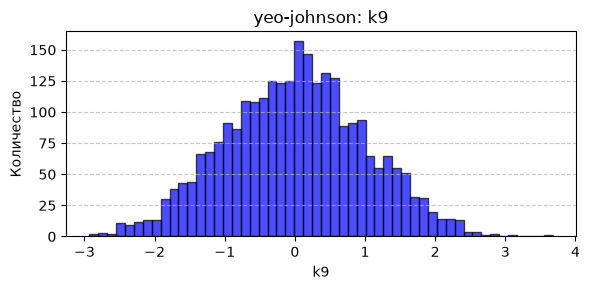

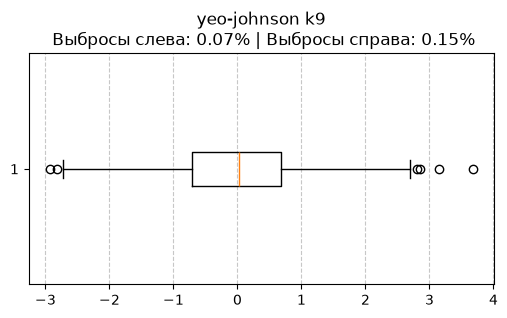

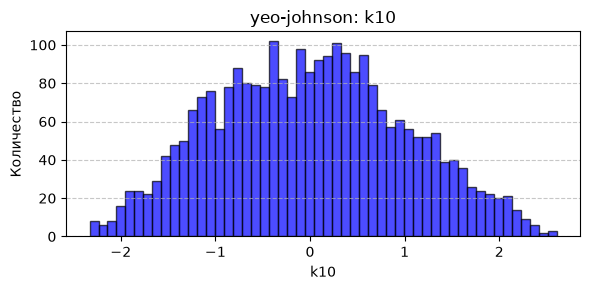

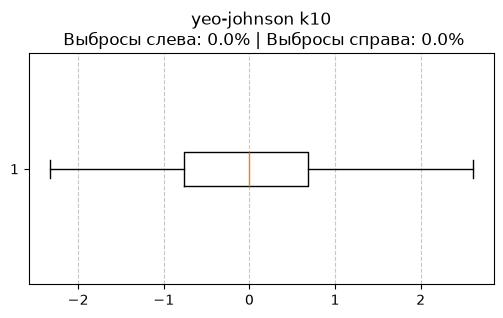

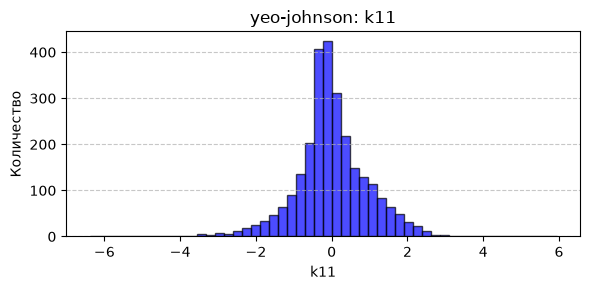

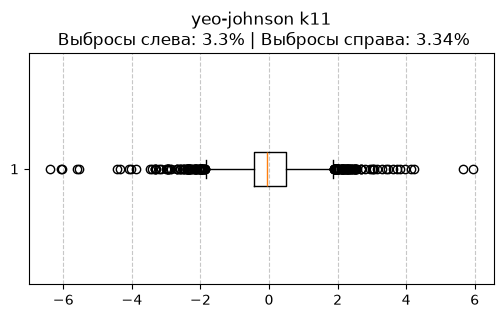

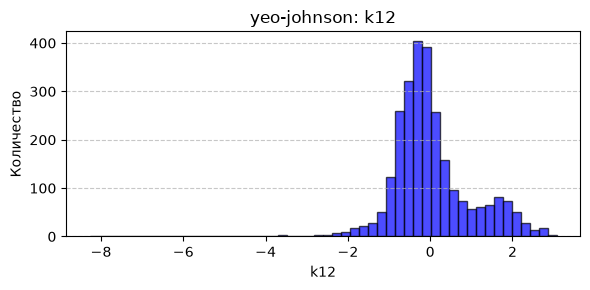

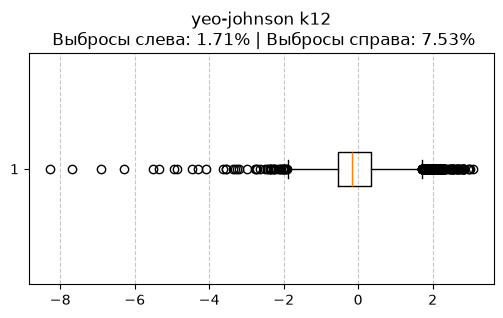

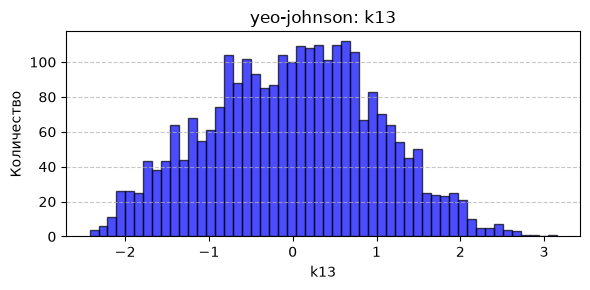

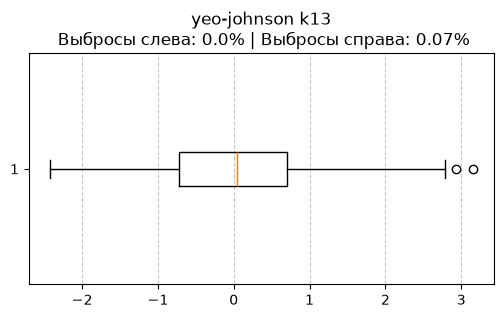

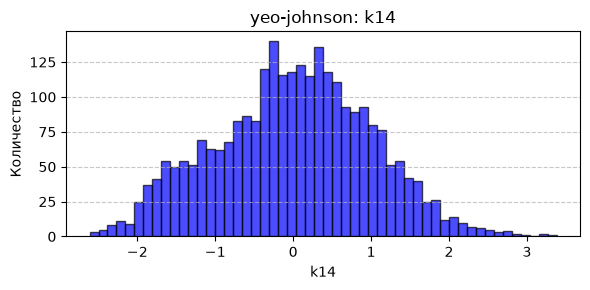

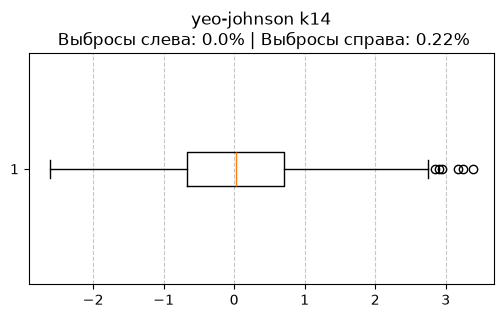

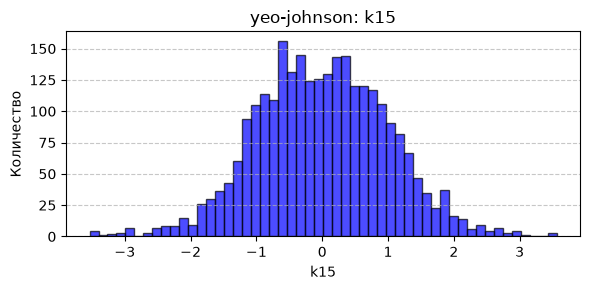

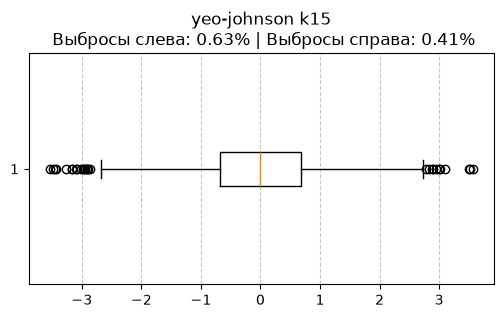

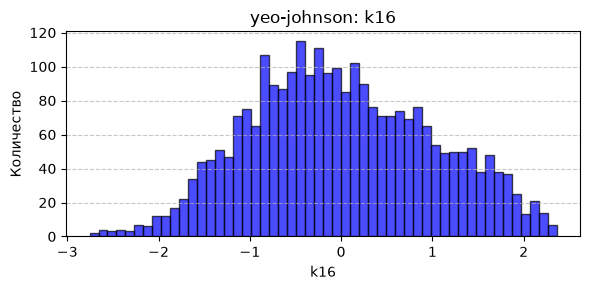

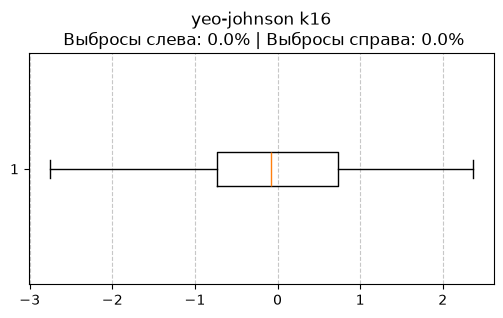

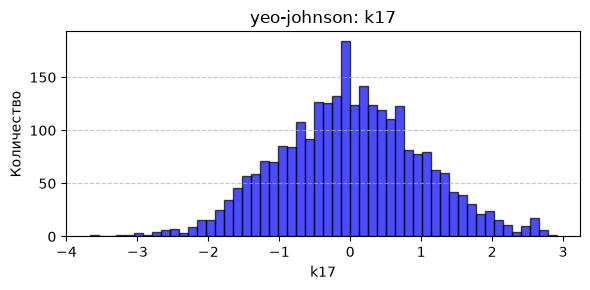

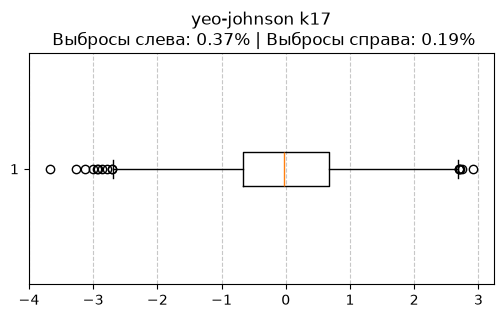

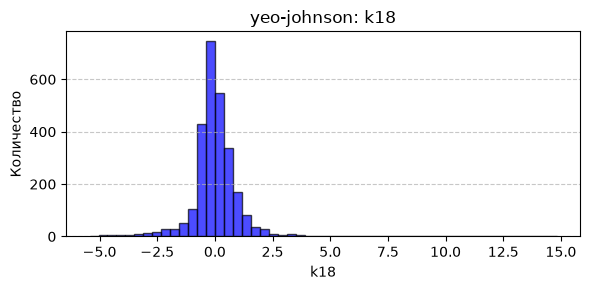

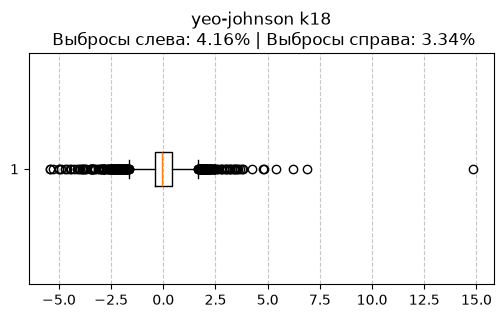

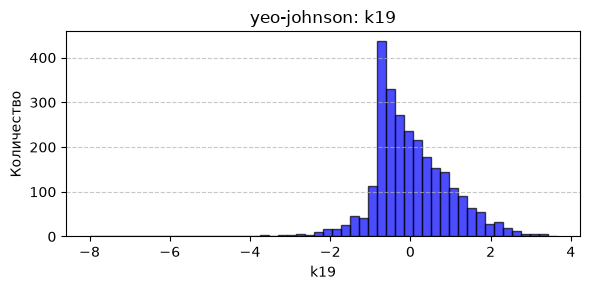

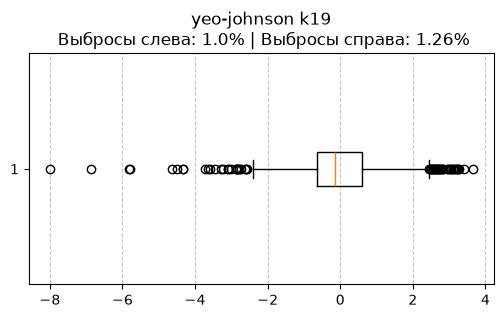

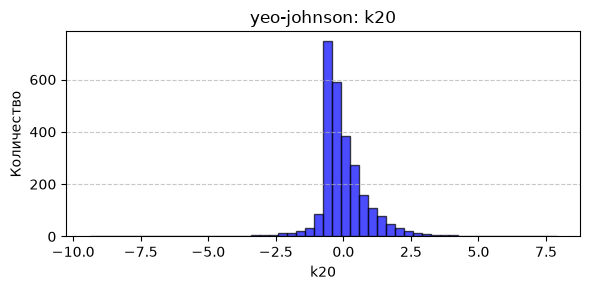

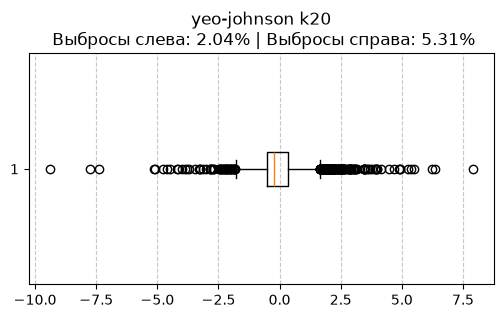

In [74]:
pt = PowerTransformer(standardize=True, method="yeo-johnson")
df2 = pd.DataFrame(pt.fit_transform(df), columns=df.columns)

for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.hist(df2[col].dropna(), bins=52, color='blue', edgecolor='black', alpha=0.7)
    plt.title(f"yeo-johnson: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")
    plt.grid(axis='y', linestyle='--', alpha = 0.7)
    plt.tight_layout() 
    plt.savefig(f'{outdir}/{col}_hist3.png')
    plt.show()

    plt.figure(figsize=(6,3))
    bp = plt.boxplot(df2[col].dropna(), orientation='horizontal')

    total_count = len(df2[col].dropna())
    left_whisker = bp['whiskers'][0].get_xdata()[0]   
    right_whisker= bp['whiskers'][1].get_xdata()[1]
    noise = bp['fliers'][0].get_xdata()

    left_noise_count = len(noise[noise < left_whisker])
    right_noise_count = len(noise[noise > right_whisker])

    if total_count > 0:
        left_prc = round((left_noise_count / total_count) * 100, 2)
        right_prc = round((right_noise_count / total_count) * 100, 2)
    else:
        left_prc = right_prc = 0.0

    summary[col] = {
        'total_count': total_count,
        'left_noise_count': left_noise_count,
        'right_noise_count': right_noise_count,
        'left_prc': left_prc,
        'right_prc': right_prc
    }


    plt.title(f"yeo-johnson {col}\n Выбросы слева: {left_prc}% | Выбросы справа: {right_prc}%")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.savefig(f'{outdir}/{col}_box4.png')
    plt.show()


In [75]:

for col in num_cols:
    prefixes = ['hist1', 'box1', 'hist2', 'box2', 'box3', 'hist3', 'box4']
    
    html_row = f"<div style='margin-bottom: 20px;'><h3>Признак: {col}</h3><div style='display: flex; gap: 20px; overflow-x: auto;'>"
    
    has_images = False
    for prefix in prefixes:
        filename = f"{col}_{prefix}.png"
        filepath = os.path.join(outdir, filename)
        
        if os.path.exists(filepath):

            html_row += f"""
            <div style='text-align: center;'>
                <span style='font-size: 12px; color: gray; display: block;'>{prefix}</span>
                <img src='{filepath}' style='max-width: 400px; height: auto; padding: 15px;' />
            </div>
            """
            has_images = True
            
    html_row += "</div></div>"
    
    if has_images:
        display(HTML(html_row))


In [76]:
scaler = StandardScaler()
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])
df_clean.describe()

,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,k9,...,k11,k12,k13,k14,k15,k16,k17,k18,k19,k20
count,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,1.540000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,...,2.695000e+03,2695.000000,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03
mean,-8.436871e-17,5.800349e-17,4.218436e-17,1.054609e-17,1.476452e-16,-2.952905e-16,3.532940e-16,-3.427479e-17,3.163827e-17,-6.723132e-17,...,1.054609e-17,0.000000,1.581913e-17,8.700523e-17,1.054609e-16,-1.054609e-17,-5.932175e-17,1.054609e-17,-1.054609e-17,4.745740e-17
std,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000325e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,...,1.000186e+00,1.000186,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00
min,-1.387661e+00,-7.121364e-01,-1.158450e+00,-2.637901e+00,-2.069101e+00,-1.606233e+00,-1.245792e+00,-8.915148e-01,-2.184589e+00,-1.447362e+00,...,-6.180278e-01,-2.603641,-1.679125e+00,-1.634746e+00,-1.530528e+00,-1.069711e+00,-6.701806e-01,-1.886522e-01,-2.775298e+00,-2.834403e+00
25%,-6.608530e-01,-6.410625e-01,-6.806825e-01,-6.401705e-01,-6.868782e-01,-7.830424e-01,-8.767233e-01,-8.848311e-01,-7.321215e-01,-7.520373e-01,...,-3.164985e-01,-0.582395,-7.613572e-01,-7.905479e-01,-8.220733e-01,-6.611484e-01,-5.395299e-01,-1.560943e-01,-7.602659e-01,-7.102683e-01
50%,-3.393338e-01,-4.810781e-01,-3.398606e-01,-1.551290e-02,3.775980e-02,-1.500177e-01,-1.597603e-01,-4.199995e-01,1.188757e-01,-1.561603e-01,...,-2.549693e-01,-0.320503,-1.390178e-01,-1.018566e-01,-3.008805e-01,-3.822183e-01,-4.030914e-01,-1.478145e-01,-2.301183e-01,-2.698555e-01
75%,3.145121e-01,1.677229e-01,2.825882e-01,7.022488e-01,7.414653e-01,6.008859e-01,6.337959e-01,7.831405e-01,8.404193e-01,4.440601e-01,...,-1.531788e-01,0.101689,5.571834e-01,5.644873e-01,5.773316e-01,2.571934e-01,-1.095114e-02,-1.375052e-01,6.868201e-01,5.579154e-01
max,2.676935e+00,2.872226e+00,2.758853e+00,2.056920e+00,2.008108e+00,3.045075e+00,2.579752e+00,2.972226e+00,1.761850e+00,3.338982e+00,...,3.974530e+00,2.737402,2.579410e+00,2.762837e+00,3.028188e+00,2.807993e+00,3.238296e+00,6.802357e+00,2.355247e+00,2.356465e+00


После масштабирования имеем среднее 0 и дисперсию 1

# КОРРЕЛЯЦИОННЫЙ АНАЛИЗ

ЗАДАЧИ ИССЛЕДОВАНИЯ:
1. Получить матрицу парных коэффициентов корреляции для всех имеющихся
показателей.
2. Выявить переменные, имеющие наиболее тесные взаимосвязи, а также
проанализировать знаки показателей корреляции.
3. Выделить переменные, которые возможно исключить из дальнейшего анализа в
силу существования тесной связи с другой/ими переменной/ыми.

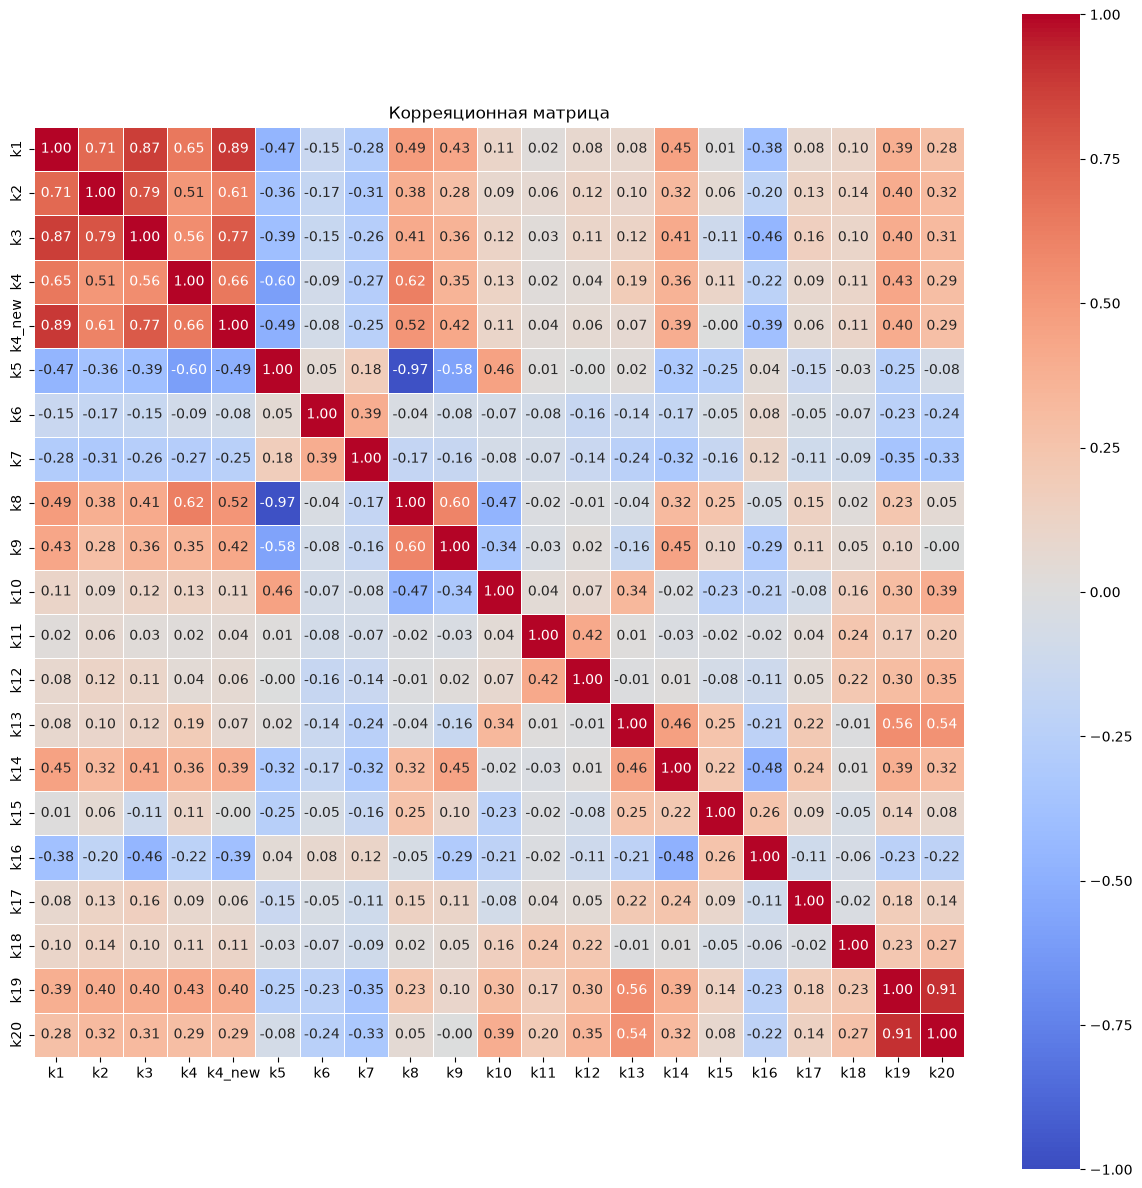

In [77]:
corr_matrix = df_clean[num_cols].corr()
plt.figure(figsize=(15,15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.4,
    square=True     
)
plt.title('Корреяционная матрица')
plt.show()

высокие корреляции у признаков К19-К20, К1-К4_new, и полная линейная зависимость у K5-K8